### Objective:

To classify Happy or Sad Emotions in Musical Audio Files using deep learning techniques. Essentially, it is a binary classification framework.

### Problem Statement

To build/develop and implement a deep learning model for the classification of emotional tones between Happy or Sad Emotions in Musical Audio Files dataset.

At the end of this competition, you will be able to:

Load and extract audio features from wave files in the Musical Audio Files dataset using librosa, encompassing MFCC (Mel-Frequency Cepstral Coefficients), Mel spectrogram, and STFT (Short-time Fourier Transform).

Develop a deep learning model utilizing either the Keras or PyTorch deep learning libraries.


### Description:

Dataset Description: The original dataset contains 7 classes but this is just a subset of the original dataset which contains 2 classes. The audio files in the dataset were already preprocessed by converting them into smaller chunks of equal size. All music were divided into 10 seconds smaller chunks using FFMPEG.

The chunks of the same song have the equally spaced names like : Happy20001-Happy20016(Same song) The last two digits resembles the chunk number while the first three digits are the ID of the original song which is provided as the GroupID. The two classes are: 1.)Happy and 2.)Sad


## Grading = 10 Marks

Here is a handy link to Kaggle's competition documentation (https://www.kaggle.com/docs/competitions), which includes, among other things, instructions on submitting predictions (https://www.kaggle.com/docs/competitions#making-a-submission).

### Instructions for downloading train and test data are as follows:

### 1. Create an API key in Kaggle.

To do this, go to the competition site on Kaggle at (https://www.kaggle.com/t/c8bda808fac2419d8025370763a90ada) and click on user then click on your profile as shown below. Click Account.

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP.PNG)

### 2. Next, scroll down to the API access section and click on **Create New Token** to download an API key (kaggle.json).

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP_1.PNG)

### 3. Upload your kaggle.json file using the following snippet in a code cell:



In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ceceliashalinidsouza","key":"ea10233ed83aa980843f052ecc7da20c"}'}

In [2]:
#If successfully uploaded in the above step, the 'ls' command here should display the kaggle.json file.
%ls

kaggle.json  sample_data/


### 4. Install the Kaggle API using the following command


In [3]:
!pip install -U -q kaggle==1.5.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentry-sdk 2.19.0 requires urllib3>=1.26.11, but you have urllib3 1.24.3 which is incompatible.


### 5. Move the kaggle.json file into ~/.kaggle, which is where the API client expects your token to be located:



In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [5]:
#Execute the following command to verify whether the kaggle.json is stored in the appropriate location: ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [6]:
!chmod 600 /root/.kaggle/kaggle.json #run this command to ensure your Kaggle API token is secure on colab

### 6. Now download the Test Data from Kaggle

**NOTE: If you get a '403 - Not Found' error after running the cell below, it is most likely that the user (whose kaggle.json is uploaded above) has not 'accepted' the rules of the competition and therefore has 'not joined' the competition.**

If you encounter **401-unauthorised** download latest **kaggle.json** by repeating steps 1 & 2

In [7]:
#If you get a forbidden link, you have most likely not joined the competition.
!kaggle competitions download -c to-classify-tones-of-musical-emotion-files
!unzip to-classify-tones-of-musical-emotion-files.zip

100% 639M/641M [00:30<00:00, 22.6MB/s]
100% 641M/641M [00:30<00:00, 22.0MB/s]
Archive:  to-classify-tones-of-musical-emotion-files.zip
  inflating: Test/Test/1.wav         
  inflating: Test/Test/10.wav        
  inflating: Test/Test/100.wav       
  inflating: Test/Test/101.wav       
  inflating: Test/Test/102.wav       
  inflating: Test/Test/103.wav       
  inflating: Test/Test/104.wav       
  inflating: Test/Test/105.wav       
  inflating: Test/Test/106.wav       
  inflating: Test/Test/107.wav       
  inflating: Test/Test/108.wav       
  inflating: Test/Test/109.wav       
  inflating: Test/Test/11.wav        
  inflating: Test/Test/110.wav       
  inflating: Test/Test/111.wav       
  inflating: Test/Test/112.wav       
  inflating: Test/Test/113.wav       
  inflating: Test/Test/114.wav       
  inflating: Test/Test/115.wav       
  inflating: Test/Test/116.wav       
  inflating: Test/Test/117.wav       
  inflating: Test/Test/118.wav       
  inflating: Test/Test/119.wa

### YOUR CODING STARTS FROM HERE

### Import Neccesary Packages

In [2]:
# YOUR CODE HERE
# Import essential libraries
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

### **Stage 1:** Load the Train data audio files (1 point)




In [3]:
# YOUR CODE HERE
# Set paths
happy_dir = "/content/Train/Happy"
sad_dir = "/content/Train/Sad"

# Load filenames
happy_files = [os.path.join(happy_dir, f) for f in os.listdir(happy_dir) if f.endswith(".wav")]
sad_files = [os.path.join(sad_dir, f) for f in os.listdir(sad_dir) if f.endswith(".wav")]

# Combine into a single dataset
all_files = happy_files + sad_files
labels = ["Happy"] * len(happy_files) + ["Sad"] * len(sad_files)

print(f"Total Happy Files: {len(happy_files)}")
print(f"Total Sad Files: {len(sad_files)}")

Total Happy Files: 828
Total Sad Files: 1045


#### Play the sample audio

In [4]:
# YOUR CODE HERE
from IPython.display import Audio

# Play a sample audio file
sample_file = happy_files[0]  # Change to sad_files[0] for a Sad example
Audio(sample_file)

### **Stage 2:** Data Exploration and Visualization (1 point)


*  Find count of each label and plot bar graph



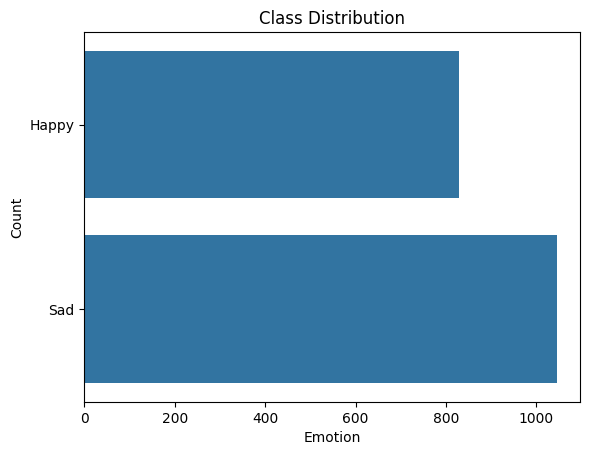

In [5]:
# YOUR CODE HERE
# Plot class distribution
sns.countplot(labels)
plt.title("Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

<ipython-input-6-05e17a1ba4e8>:2: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  durations = [librosa.get_duration(filename=f) for f in all_files]
<ipython-input-6-05e17a1ba4e8>:2: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  durations = [librosa.get_duration(filename=f) for f in all_files]
<ipython-input-6-05e17a1ba4e8>:2: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  durations = [librosa.get_duration(filename=f) for f in all_files]


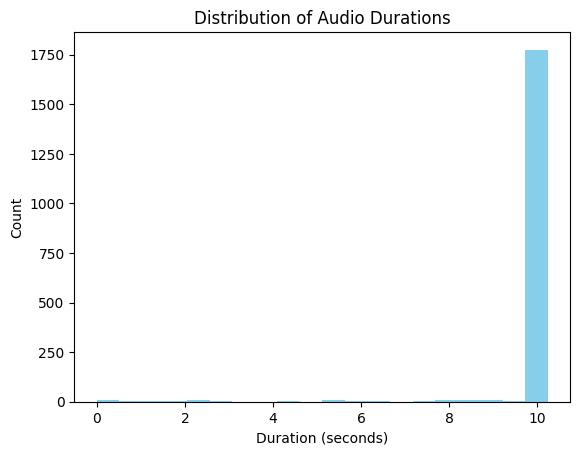

In [6]:
# Check the duration of a few sample files
durations = [librosa.get_duration(filename=f) for f in all_files]

plt.hist(durations, bins=20, color='skyblue')
plt.title("Distribution of Audio Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

In [15]:
print(durations)

[10.013242630385488, 10.012222222222222, 10.013265306122449, 10.016645833333333, 9.987732426303856, 10.01249433106576, 10.016833333333333, 10.012312925170068, 9.987777777777778, 10.01390022675737, 10.012857142857143, 2.0726303854875283, 10.011655328798186, 0.05658333333333333, 9.992895833333334, 9.935374149659864, 10.013786848072563, 9.987528344671201, 10.013650793650793, 9.987120181405896, 10.013650793650793, 10.013786848072563, 10.013650793650793, 10.013492063492064, 10.013741496598639, 10.01249433106576, 9.992333333333333, 10.021700680272108, 10.013401360544218, 10.021904761904763, 10.01249433106576, 10.013741496598639, 5.389977324263039, 10.021904761904763, 10.013605442176871, 10.013650793650793, 10.013650793650793, 8.054467120181405, 10.014036281179138, 10.013650793650793, 10.017895833333334, 9.98716553287982, 10.013650793650793, 10.013605442176871, 10.01344671201814, 10.013492063492064, 10.016333333333334, 9.992833333333333, 10.013786848072563, 10.012562358276645, 10.016833333333

In [7]:
# find files with short duration OPtional
short_files = []

for file in all_files:
    duration = librosa.get_duration(filename=file)
    if duration < 5:  # Check for files less than 5 seconds
        short_files.append((file, duration))


<ipython-input-7-028529779c05>:5: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  duration = librosa.get_duration(filename=file)
<ipython-input-7-028529779c05>:5: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  duration = librosa.get_duration(filename=file)
<ipython-input-7-028529779c05>:5: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  duration = librosa.get_duration(filename=file)


In [8]:

# Print files with durations less than 5 seconds
if short_files:
    print(len(short_files))
    print("Files with duration less than 5 seconds:")
    for file, duration in short_files:
        print(f"File: {file}, Duration: {duration:.2f}s")
else:
    print("No files with duration less than 5 seconds found.")

44
Files with duration less than 5 seconds:
File: /content/Train/Happy/Happy36523.wav, Duration: 2.07s
File: /content/Train/Happy/Happy18103.wav, Duration: 0.06s
File: /content/Train/Happy/Happy43425.wav, Duration: 2.05s
File: /content/Train/Happy/Happy21419.wav, Duration: 1.34s
File: /content/Train/Happy/Happy25603.wav, Duration: 0.06s
File: /content/Train/Happy/Happy22017.wav, Duration: 4.21s
File: /content/Train/Happy/Happy39112.wav, Duration: 0.06s
File: /content/Train/Happy/Happy33613.wav, Duration: 2.05s
File: /content/Train/Happy/Happy38217.wav, Duration: 1.88s
File: /content/Train/Happy/Happy39903.wav, Duration: 0.06s
File: /content/Train/Happy/Happy13216.wav, Duration: 2.23s
File: /content/Train/Happy/Happy19918.wav, Duration: 0.98s
File: /content/Train/Happy/Happy28325.wav, Duration: 4.50s
File: /content/Train/Happy/Happy14418.wav, Duration: 0.79s
File: /content/Train/Happy/Happy41813.wav, Duration: 2.41s
File: /content/Train/Happy/Happy38918.wav, Duration: 0.92s
File: /conte

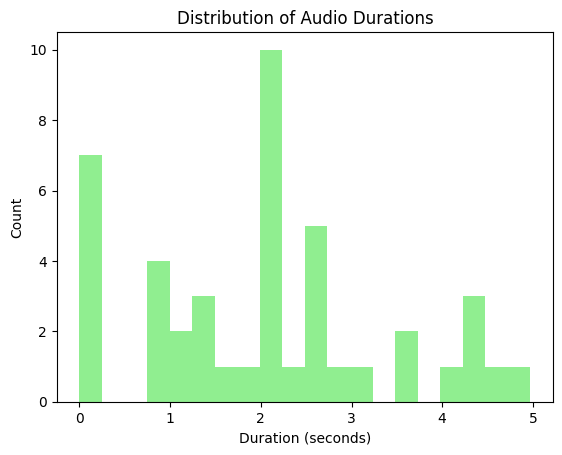

In [9]:
short_durns = [item[1] for item in short_files]
plt.hist(short_durns, bins=20, color='lightgreen')
plt.title("Distribution of Audio Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

#### Visualize sample audio signal using librosa

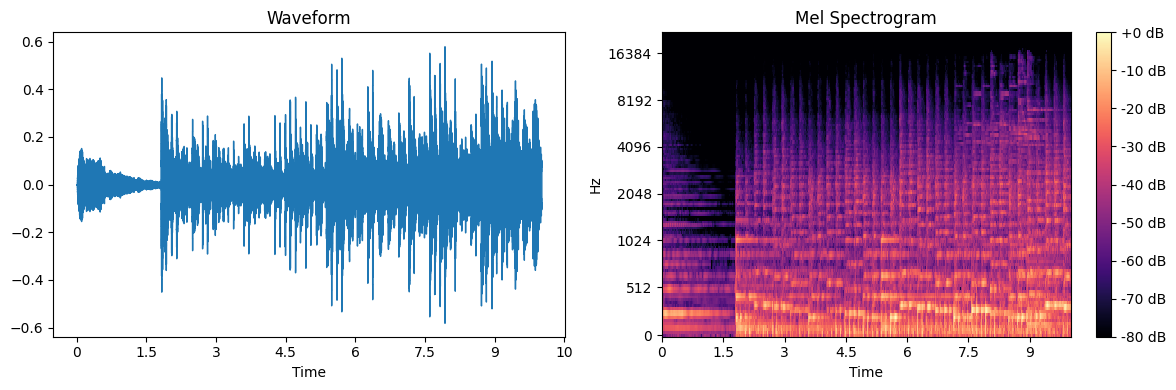

In [10]:
# YOUR CODE HERE
# sample_file = happy_files[0]  # Change to sad_files[0] for a Sad example
# Visualize audio signal
y, sr = librosa.load(sample_file, sr=None)
plt.figure(figsize=(12, 4))

# Plot waveform
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")

# Plot spectrogram
plt.subplot(1, 2, 2)
spec = librosa.feature.melspectrogram(y=y, sr=sr)
librosa.display.specshow(librosa.power_to_db(spec, ref=np.max), sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")

plt.tight_layout()
plt.show()

### **Stage 3:** Feature extraction (2 points)


In [11]:
# YOUR CODE HERE
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

    # Aggregate features
    features = np.hstack((
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.mean(chroma, axis=1),
        np.std(chroma, axis=1),
        np.mean(contrast, axis=1),
        np.std(contrast, axis=1)
    ))
    return features

# Extract features for the entire dataset
X = np.array([extract_features(f) for f in all_files])
encoder = LabelEncoder()
y = encoder.fit_transform(labels)

/usr/local/lib/python3.10/dist-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
<ipython-input-11-2e83e3c3b1fa>:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.10/dist-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
<ipython-input-11-2e83e3c3b1fa>:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa ver

# Histogram of Individual Features:
You can visualize the distribution of each extracted feature, such as the mean and standard deviation of MFCC, chroma, and spectral contrast.

Why: Histograms allow you to understand the spread and central tendency of each feature. It can also help you identify if certain features are more common for "Happy" or "Sad" labels.

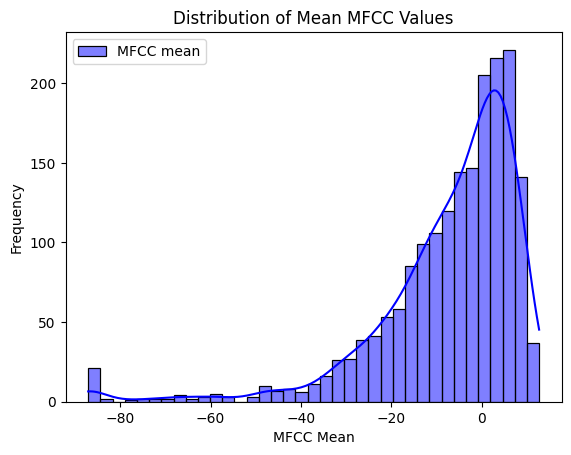

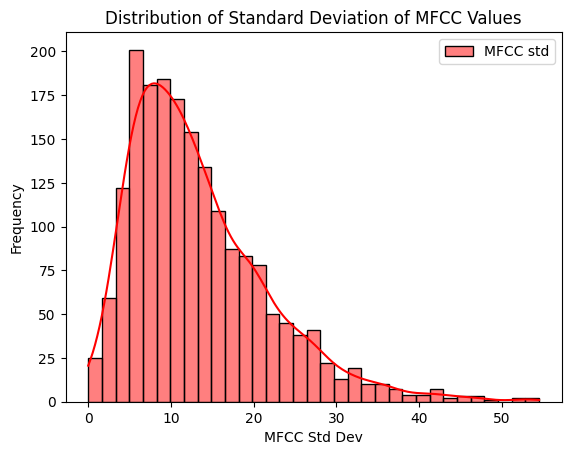

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms for mean MFCC values
sns.histplot(X[:, 0:13].mean(axis=1), kde=True, color="blue", label="MFCC mean")
plt.title("Distribution of Mean MFCC Values")
plt.xlabel("MFCC Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Plot histograms for standard deviation of MFCC values
sns.histplot(X[:, 13:26].std(axis=1), kde=True, color="red", label="MFCC std")
plt.title("Distribution of Standard Deviation of MFCC Values")
plt.xlabel("MFCC Std Dev")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Pairwise Scatter Plots:
Pairwise scatter plots (or pairplots) can help visualize the relationships between two or more features at once, and how they may differ between classes (Happy vs. Sad). For example, plot mean MFCC vs. mean chroma or mean contrast vs. mean MFCC.

Why: It can show how features like MFCC, chroma, and contrast are distributed for each label and whether they show separability.

In [13]:
import seaborn as sns
import pandas as pd

# Combine the features and labels into a DataFrame
df = pd.DataFrame(X)
df['label'] = y  # Adding labels to the DataFrame


In [40]:
# # Takes lot of time execute if needed!
# # Pairplot to visualize feature relationships
# sns.pairplot(df, hue='label')
# plt.show()

Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x7af6b5944820>
Traceback (most recent call last):
  File "/usr/lib/python3.10/weakref.py", line 370, in remove
    def remove(k, selfref=ref(self)):
KeyboardInterrupt: 
Exception ignored in: <function _xla_gc_callback at 0x7af632e90160>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7af6b575a4d0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7af6b57591b0> (for post_execute):


KeyboardInterrupt: 

# Boxplots for Feature Distribution:

Boxplots are useful to visualize the distribution of feature values, especially for detecting outliers and comparing the spread of features between different classes (Happy vs. Sad).

Why: Boxplots will give you insights into the median, quartiles, and outliers for each feature across the classes.

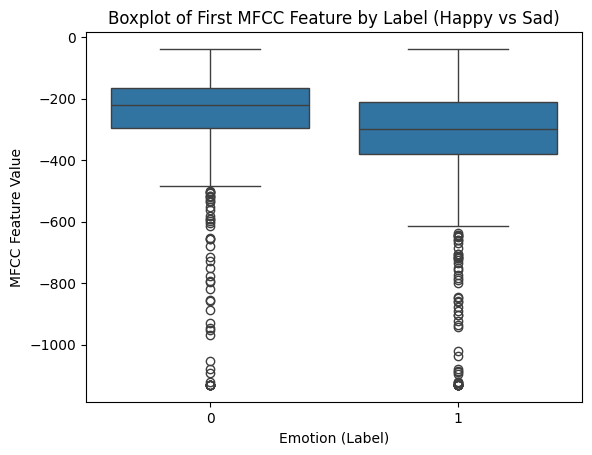

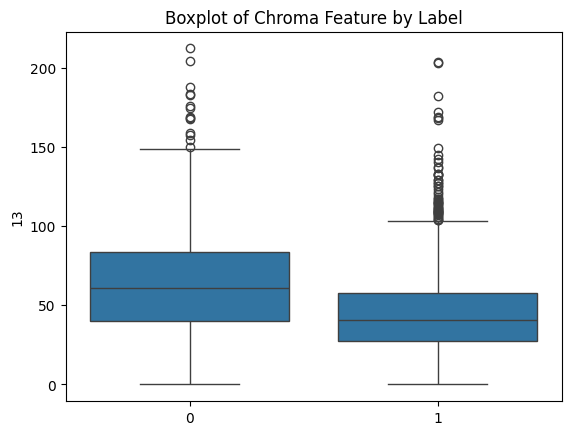

In [14]:
sns.boxplot(x=y, y=df[0])  # Boxplot for a particular feature (e.g., first MFCC feature)
plt.title("Boxplot of First MFCC Feature by Label (Happy vs Sad)")
plt.xlabel("Emotion (Label)")
plt.ylabel("MFCC Feature Value")
plt.show()

sns.boxplot(x=y, y=df[13])  # Boxplot for a particular feature (e.g., first chroma feature)
plt.title("Boxplot of Chroma Feature by Label")
plt.show()

# Principal Component Analysis (PCA):
Use PCA to reduce the dimensionality of your feature set (from many features like MFCC, chroma, and contrast) into two or three components. This can help visualize how the data points (Happy vs. Sad) are separated in a lower-dimensional space.

Why: PCA can help you visualize whether the data points are well-separated along the first few components and if the features lead to a clear distinction between classes.

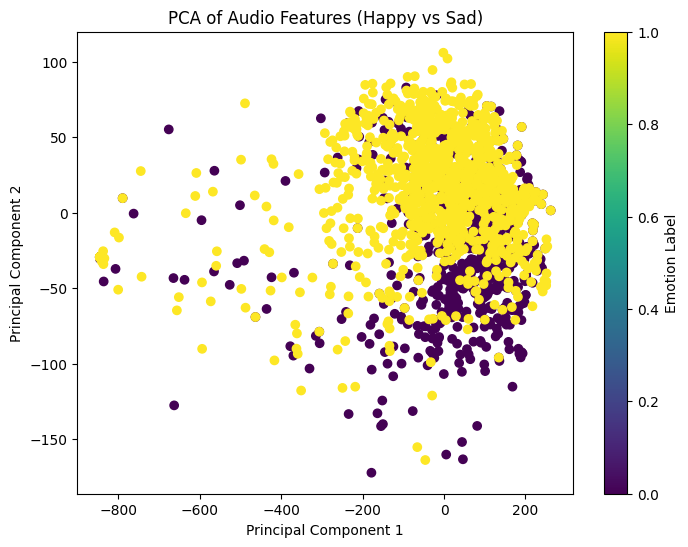

In [15]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot the 2D projection of PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title("PCA of Audio Features (Happy vs Sad)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Emotion Label")
plt.show()

# Correlation Matrix:
A correlation matrix can help you visualize relationships between the extracted features. This will allow you to identify which features are correlated and whether some features are highly correlated with each other.

Why: Highly correlated features may not provide additional useful information, and you may want to consider dimensionality reduction or feature selection if necessary.

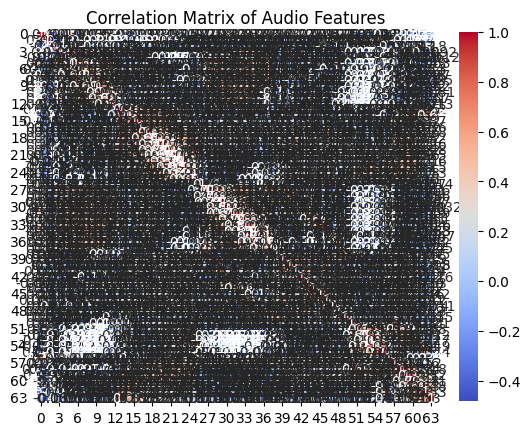

In [16]:
import seaborn as sns
import numpy as np

# Correlation matrix of the features
corr_matrix = np.corrcoef(X, rowvar=False)

# Plotting the heatmap of the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Audio Features")
plt.show()

### **Stage 4:** Train the model  (4 points)


In [17]:
# YOUR CODE HERE
# Split dataset
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Sequential name=sequential, built=True>


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,641 (65.00 KB)

 Trainable params: 16,641 (65.00 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [20]:
# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=32)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5355 - loss: 6.8748 - val_accuracy: 0.6533 - val_loss: 1.1629
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6527 - loss: 2.0552 - val_accuracy: 0.6613 - val_loss: 0.9064
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5889 - loss: 1.5478 - val_accuracy: 0.6640 - val_loss: 0.6354
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6362 - loss: 1.0150 - val_accuracy: 0.7120 - val_loss: 0.6803
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6312 - loss: 0.8648 - val_accuracy: 0.7147 - val_loss: 0.6587
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6462 - loss: 0.7939 - val_accuracy: 0.7200 - val_loss: 0.6419
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6711 - loss: 0.7096 - val_accuracy: 0.6773 - val_loss: 0.6392
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6976 - loss: 0.6728 - val_accuracy: 0.6720 - val_los

# Accuracy Plots

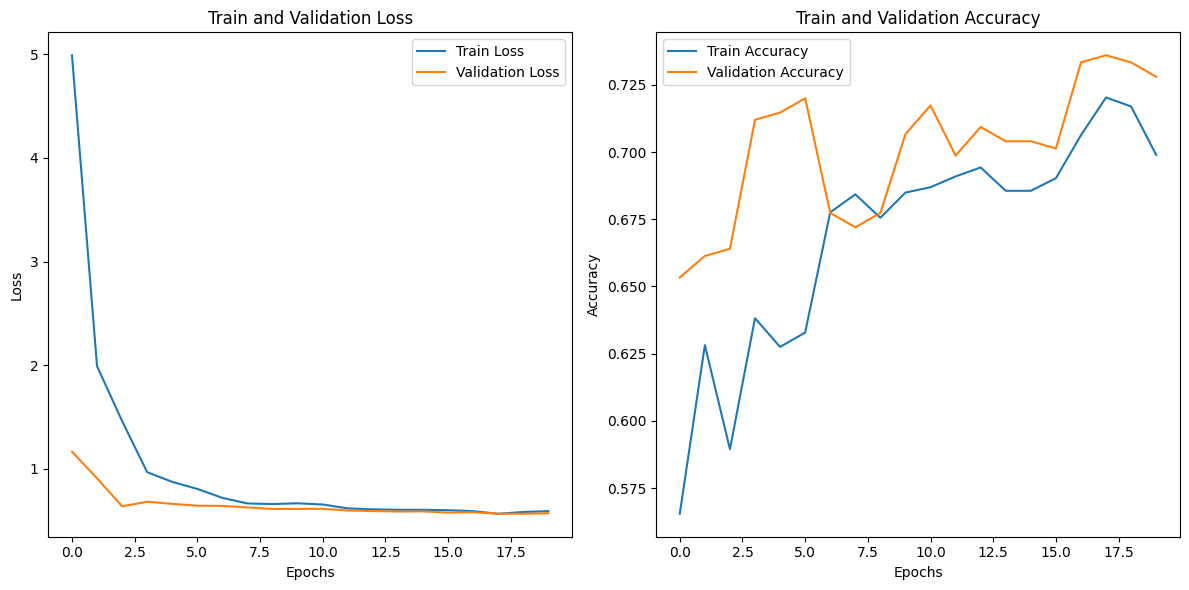

In [22]:
# Plot training & validation loss values
plt.figure(figsize=(12, 6))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Train and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Train and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


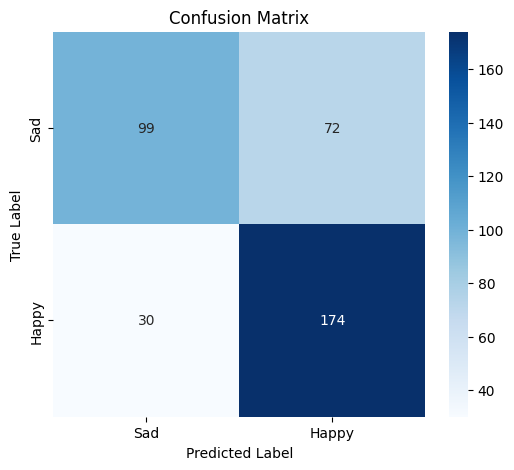

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict on validation data
y_pred = model.predict(X_val)
y_pred = (y_pred > 0.5).astype(int)  # Convert to binary labels (0 or 1)

# Calculate confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Sad", "Happy"], yticklabels=["Sad", "Happy"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ROC Curve:
A Receiver Operating Characteristic (ROC) curve is another useful visualization for binary classification, showing the trade-off between true positive rate (sensitivity) and false positive rate.

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


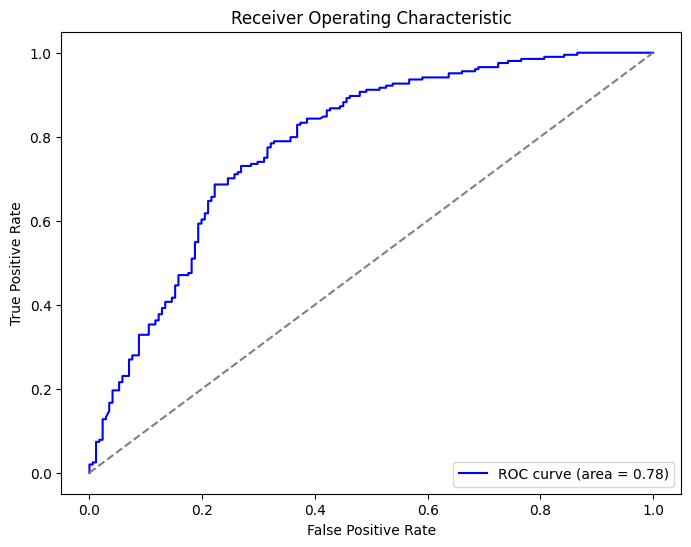

In [24]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_val, model.predict(X_val))
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.title('Receiver Operating Characteristic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve:
This curve is useful when the classes are imbalanced. It shows the trade-off between precision and recall.

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


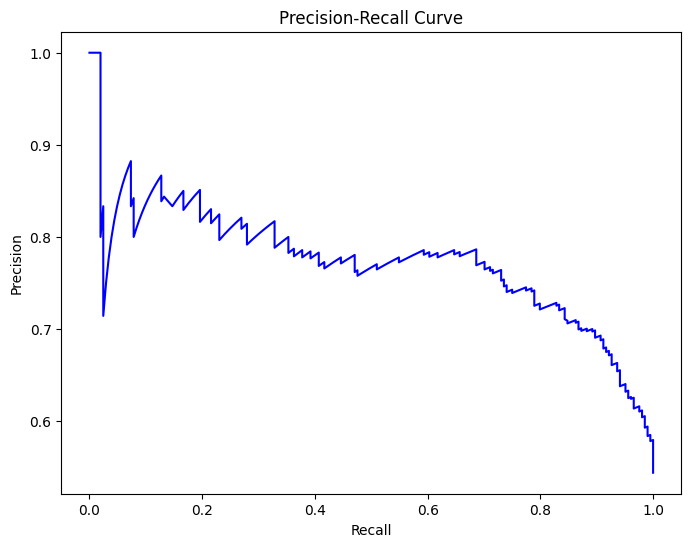

In [25]:
from sklearn.metrics import precision_recall_curve

# Compute precision-recall curve
precision, recall, _ = precision_recall_curve(y_val, model.predict(X_val))

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

### **Stage 5:** Kaggle Testset predictions (2 points)



*   Load the test set and extract the features of the .wav files
*   Using the trained model get the predicions on the test set
*   Finally, upload your predictions to the kaggle



In [26]:
# YOUR CODE HERE
test_dir = "/content/Test"
test_files = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith(".wav")]

X_test = np.array([extract_features(f) for f in test_files])

/usr/local/lib/python3.10/dist-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


In [27]:
# Predict using trained model
predictions = model.predict(X_test)
predicted_labels = (predictions > 0.5).astype(int)
predicted_classes = encoder.inverse_transform(predicted_labels.flatten())

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [28]:
# Save predictions to CSV
submission = pd.DataFrame({
    "File Name": [os.path.basename(f) for f in test_files],
    "Target": predicted_classes
})
submission.to_csv("submission.csv", index=False)

print("Submission file generated: submission.csv")

Submission file generated: submission.csv
